In [1]:
# SECTION 1
# libraries
import warnings
from pathlib import Path
from itertools import combinations
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings("ignore")

# constants
DATASET_ROOT = Path(r"C:\Users\ASUS\Desktop\New folder (2)\Cataract_dataset_classification.v1i.multiclass")
SPLITS       = ["train", "valid", "test"]
CSV_NAME     = "_classes.csv"
OUTPUT_DIR   = Path(r"C:\Users\ASUS\Desktop\New folder (2)\analysis_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# shortened labels for display
SHORT = {
    "Cannula"          : "Cannula",
    "Cap Cystotome"    : "Cap Cyst.",
    "Cap Forceps"      : "Cap Forc.",
    "Cornea"           : "Cornea",
    "Forceps"          : "Forceps",
    "I-A Handpiece"    : "I-A Hand.",
    "Lens Injector"    : "Lens Inj.",
    "Phaco Handpiece"  : "Phaco H.",
    "Primary Knife"    : "Prim. Kn.",
    "Pupil"            : "Pupil",
    "Second Instrument": "Sec. Inst.",
    "Secondary Knife"  : "Sec. Kn.",
}

# step 1: load the data 
def load_split(split: str) -> pd.DataFrame:
    csv_path = DATASET_ROOT / split / CSV_NAME
    
    # double check if file exists
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing CSV file at: {csv_path.resolve()}")

    # load csv as pandas dataFrame    
    df = pd.read_csv(csv_path)

    # remove extra spaces 
    df.columns = [c.strip() for c in df.columns]

    df.rename(columns={df.columns[0]: "filename"}, inplace=True)

    # new column for separating data into train, valid & test
    df["split"] = split

    return df

# step 2: merge data
print("-> loading data")

# store each split dataFrame into a dict
dfs    = {s: load_split(s) for s in SPLITS}

# stack the 3 splits into one dataFrame
df_all = pd.concat(dfs.values(), ignore_index=True)

# set of the non-tool columns (like cornea & pupil)
META_COLS  = {"filename", "split"}

# list of the tool columns
CLASS_COLS = [c for c in df_all.columns if c not in META_COLS]
# count of all tool classes
N          = len(CLASS_COLS)
# use the name in SHORT dictionary
SLABELS    = [SHORT.get(c, c) for c in CLASS_COLS]

# count the num of tools in each image
df_all["n_labels"]    = df_all[CLASS_COLS].sum(axis=1).astype(int)
# if no tools in the image = true (neg frame)
df_all["is_negative"] = df_all["n_labels"] == 0

# remove this
#df_all["source_type"] = df_all["filename"].str.extract(r'^(Video\d+|case\d+)')[0].fillna("other")

# reseperate df_all into dictionaries for each split
for s in SPLITS:
    dfs[s] = df_all[df_all["split"] == s].copy()

# colors for plots
CMAP      = plt.cm.get_cmap("tab20", N)
BAR_COLS  = [CMAP(i) for i in range(N)]
SP_COLORS = {"train": "#4C72B0", "valid": "#DD8452", "test": "#55A868"}


-> loading data


In [2]:
# SECTION 2: TEXT
# includes cornea & pupil

# visual
DIV = "─" * 65

print(DIV)
print(f"    (A) OVERVIEW:   ")
print(DIV)

# count total images
total = len(df_all)
print(f"total images: {total:,}")

# num of classes
print(f"class columns: {N}")
print(f"name of classes: {CLASS_COLS}")
print()
print("split | images | percentage | negative frames | avg labels")
print(DIV)

# loop that repeats 3 times for train, valid & test
for s in SPLITS:
    d   = dfs[s]
    n   = len(d)

    # num of neg frames
    neg = d["is_negative"].sum()

    # avg num of tools in images
    avg = d["n_labels"].mean()

    # calculate percentages
    pct = (n / total) * 100
    neg_pct = (neg / n) * 100

    print(f"{s} | {n} | {pct:.1f}% | {neg} ({neg_pct:.0f}%) | {avg:.2f}")

print()
print(DIV)
print(f"    (B) LABEL-COUNT DISTRIBUTION:   ")
print(DIV)
for s in SPLITS:
    lc = dfs[s]["n_labels"].value_counts().sort_index()
    print(f"\n  [{s}]")

    # print raw num and percentage
    for k, v in lc.items():
       pct = (v / len(dfs[s])) * 100
       print(f"  {k} class(es): {v} ({pct:.1f}%)")

print()
print(DIV)
print(f"    (C) PER-CLASS FREQUENCY:    ")
print(DIV)

print("Class | Train | Val | Test | Total | % Total | Severity")
print(DIV)

# loop that repeats for each class
for cls in CLASS_COLS:

    # per split values
    train_num = int(dfs["train"][cls].sum())
    valid_num = int(dfs["valid"][cls].sum())
    test_num  = int(dfs["test"][cls].sum())

    # adds per split values 
    tot = train_num + valid_num + test_num

    # (data set that has this tool/ total data set)%
    pct = tot / total * 100

    # imbalance label 
    # > 30 (ok), 10 < < 30 (mod.), < 10 (sev.)
    if pct >= 30:
        sev = "OK"
    elif pct >= 10:
        sev = "moderate"
    else:
        sev = "severe"

    print(f"{cls} | {train_num} | {valid_num} | {test_num} | {tot} | {pct:.1f}% | {sev}")

# num of appearances of each class in train
train_counts = np.array([dfs["train"][c].sum() for c in CLASS_COLS], dtype=float)

# imbalance ratio (most freq/least freq)
train_counts = np.array([dfs["train"][c].sum() for c in CLASS_COLS], dtype=float)
max_val = train_counts.max()
min_val = max(train_counts.min(), 1) 
ratio = max_val / min_val

print(f"\nmax-to-min imbalance ratio (in train): {max_val:.0f} / {min_val:.0f} = {ratio:.1f}x")

# co-occurrence matrix 
# how often tools are used together
co = np.zeros((N, N), dtype=int)
label_mat = dfs["train"][CLASS_COLS].values

# loop that repeats for all imgs (rows of the .csv)
for row in label_mat:
    # finds all 1s
    idxs = np.where(row == 1)[0]
    # finds all possible combos (intersection points)
    for a, b in combinations(idxs, 2):
        co[a, b] += 1;  co[b, a] += 1

# final dataFrame
co_df = pd.DataFrame(co, index=CLASS_COLS, columns=CLASS_COLS)

print(DIV)
print(co_df.to_string())

print(DIV)
print("DONE.")


─────────────────────────────────────────────────────────────────
    (A) OVERVIEW:   
─────────────────────────────────────────────────────────────────
total images: 6,962
class columns: 12
name of classes: ['Cannula', 'Cap Cystotome', 'Cap Forceps', 'Cornea', 'Forceps', 'I-A Handpiece', 'Lens Injector', 'Phaco Handpiece', 'Primary Knife', 'Pupil', 'Second Instrument', 'Secondary Knife']

split | images | percentage | negative frames | avg labels
─────────────────────────────────────────────────────────────────
train | 5136 | 73.8% | 0 (0%) | 3.07
valid | 991 | 14.2% | 0 (0%) | 3.13
test | 835 | 12.0% | 0 (0%) | 3.06

─────────────────────────────────────────────────────────────────
    (B) LABEL-COUNT DISTRIBUTION:   
─────────────────────────────────────────────────────────────────

  [train]
  1 class(es): 115 (2.2%)
  2 class(es): 556 (10.8%)
  3 class(es): 3343 (65.1%)
  4 class(es): 1122 (21.8%)

  [valid]
  1 class(es): 11 (1.1%)
  2 class(es): 104 (10.5%)
  3 class(es): 619 (6

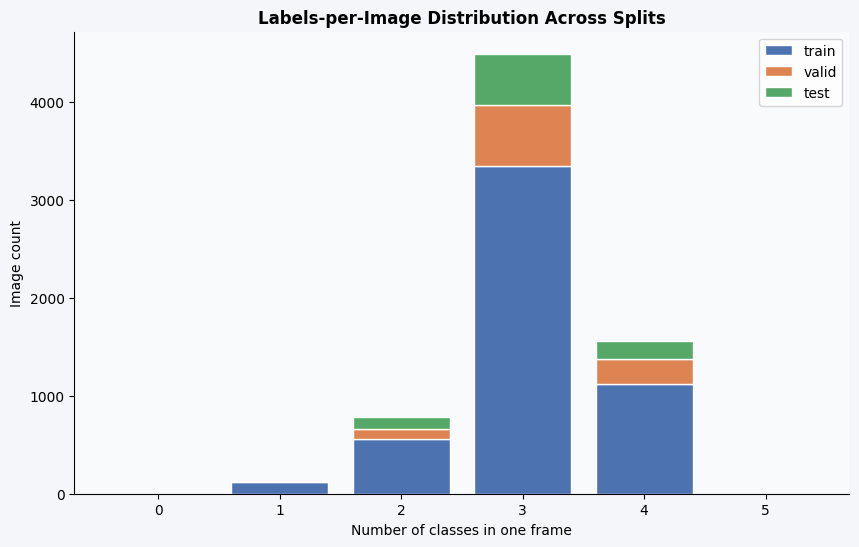

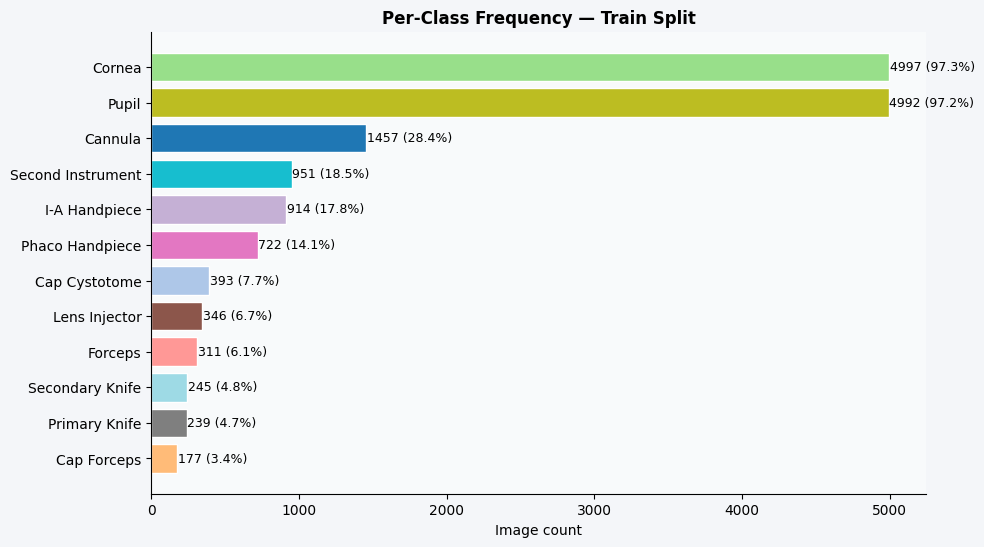

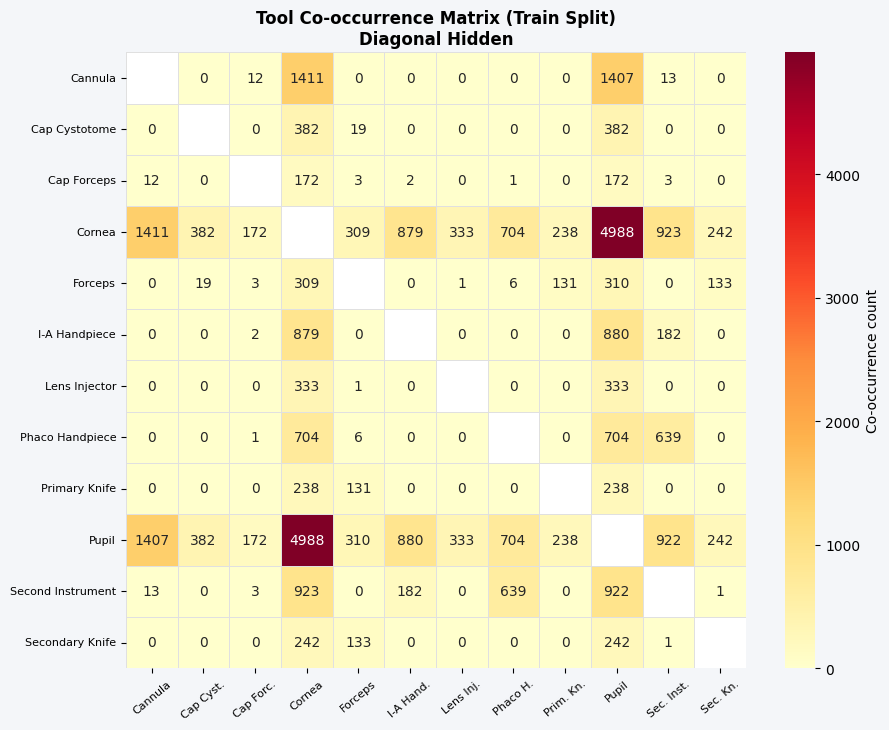

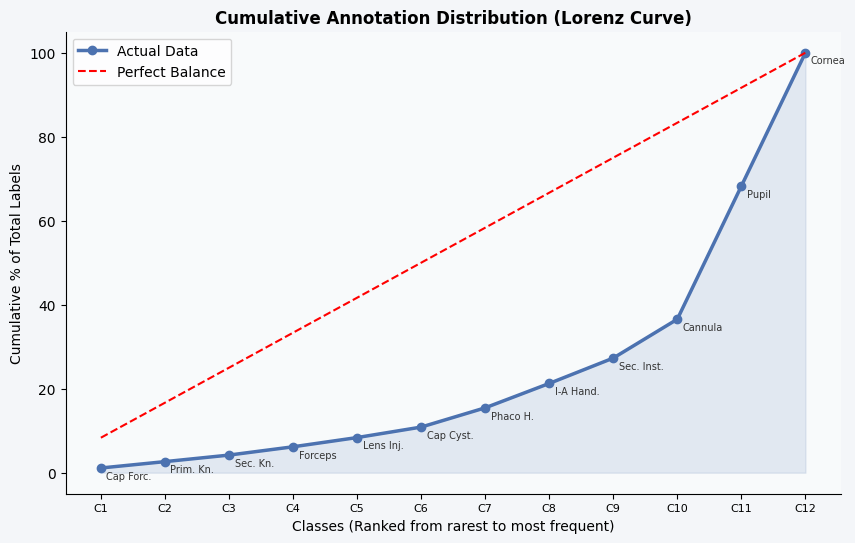

In [3]:
# SECTION 3: FIG
# includes cornea & pupil

# chart backgrounds
def style_chart(ax):
    ax.set_facecolor("#F8FAFB")
    ax.spines[["top", "right"]].set_visible(False)


# FIG1: label per img

fig1, ax1 = plt.subplots(figsize=(10, 6))
fig1.patch.set_facecolor("#F4F6F9")
style_chart(ax1)

# max num of classes
max_lbl = int(df_all["n_labels"].max())
x_vals  = list(range(max_lbl + 1))
bottom  = np.zeros(len(x_vals))

# chart for all splits
for s in SPLITS:
    lc = dfs[s]["n_labels"].value_counts().reindex(x_vals, fill_value=0)
    ax1.bar(x_vals, lc.values, bottom=bottom, label=s, color=SP_COLORS[s], edgecolor="white")
    bottom += lc.values  

# labels and titles
ax1.set_title("Labels-per-Image Distribution Across Splits", fontweight="bold")
ax1.set_xlabel("Number of classes in one frame")
ax1.set_ylabel("Image count")
ax1.set_xticks(x_vals)
ax1.legend()

plt.show()

# FIG2: per class freq (in train)

fig2, ax2 = plt.subplots(figsize=(10, 6))
fig2.patch.set_facecolor("#F4F6F9")
style_chart(ax2)

# sort classes (most to least freq)
sort_idx = np.argsort(train_counts)[::-1]
s_cls    = [CLASS_COLS[i] for i in sort_idx]
s_cnt    = [train_counts[i] for i in sort_idx]
s_cols   = [BAR_COLS[i] for i in sort_idx]

# draw
hb = ax2.barh(s_cls, s_cnt, color=s_cols, edgecolor="white")
ax2.set_title("Per-Class Frequency — Train Split", fontweight="bold")
ax2.set_xlabel("Image count")
ax2.invert_yaxis()

# add nums
for bar, v in zip(hb, s_cnt):
    pct = (v / len(dfs['train'])) * 100
    ax2.text(v + 3, bar.get_y() + bar.get_height()/2, f"{int(v)} ({pct:.1f}%)", va="center", fontsize=9)

plt.show()


# FIG3: Co-occurrence Heatmap

fig3, ax3 = plt.subplots(figsize=(10, 8))
fig3.patch.set_facecolor("#F4F6F9")

# hiding the class matching itself
mask = np.eye(N, dtype=bool)

# draw
sns.heatmap(co_df, ax=ax3, annot=True, fmt="d", cmap="YlOrRd",
            mask=mask, linewidths=0.6, linecolor="#e0e0e0",
            xticklabels=SLABELS, yticklabels=CLASS_COLS,
            cbar_kws={"label": "Co-occurrence count"})

ax3.set_title("Tool Co-occurrence Matrix (Train Split)\nDiagonal Hidden", fontweight="bold")
ax3.tick_params(axis="x", rotation=40, labelsize=8)
ax3.tick_params(axis="y", rotation=0, labelsize=8)

plt.show()

# FIGURE 4: Lorenz Curve (Imbalance Diagnostics)

fig4, ax4 = plt.subplots(figsize=(10, 6))
fig4.patch.set_facecolor("#F4F6F9")
style_chart(ax4)

# cummulative percentages
sorted_counts = np.sort(train_counts)
cum_pct = np.cumsum(sorted_counts) / sorted_counts.sum() * 100

# data set line in blue
ax4.plot(range(1, N+1), cum_pct, marker="o", color="#4C72B0", linewidth=2.5, label="Actual Data")
ax4.fill_between(range(1, N+1), cum_pct, alpha=0.13, color="#4C72B0")

# ideal data set in red
ax4.plot([1, N], [100/N, 100], "r--", linewidth=1.5, label="Perfect Balance")

# label
ax4.set_xticks(range(1, N+1))
ax4.set_xticklabels([f"C{i+1}" for i in range(N)], fontsize=8)
ax4.set_xlabel("Classes (Ranked from rarest to most frequent)")
ax4.set_ylabel("Cumulative % of Total Labels")
ax4.set_title("Cumulative Annotation Distribution (Lorenz Curve)", fontweight="bold")
ax4.legend()

ranked_cls = [CLASS_COLS[j] for j in np.argsort(train_counts)]
for i, (xp, yp, cls) in enumerate(zip(range(1, N+1), cum_pct, ranked_cls)):
    ax4.annotate(SHORT.get(cls, cls), (xp, yp), textcoords="offset points", 
                 xytext=(4, -8), fontsize=7, color="#333333")

plt.show()

In [4]:
# SECTION 2*: TEXT
# SURGICAL TOOLS ONLY (CORNEA AND PUPIL EXCLUDED)

# update class list 
CLASS_COLS = [c for c in CLASS_COLS if c not in ["Cornea", "Pupil"]]
N = len(CLASS_COLS)

# recalculate num of imgs and neg frames
df_all["n_labels"] = df_all[CLASS_COLS].sum(axis=1).astype(int)
df_all["is_negative"] = df_all["n_labels"] == 0

# new values for each split
for s in SPLITS:
    dfs[s] = df_all[df_all["split"] == s].copy()

# visual
DIV = "─" * 65

print(DIV)
print(f"    (A) OVERVIEW:   ")
print(DIV)

# count total images
total = len(df_all)
print(f"total images: {total:,}")

# num of classes
print(f"class columns: {N}")
print(f"name of classes: {CLASS_COLS}")
print()
print("split | images | percentage | negative frames | avg labels")
print(DIV)

# loop that repeats 3 times for train, valid & test
for s in SPLITS:
    d   = dfs[s]
    n   = len(d)

    # num of neg frames
    neg = d["is_negative"].sum()

    # avg num of tools in images
    avg = d["n_labels"].mean()

    # calculate percentages
    pct = (n / total) * 100
    neg_pct = (neg / n) * 100

    print(f"{s} | {n} | {pct:.1f}% | {neg} ({neg_pct:.0f}%) | {avg:.2f}")

print()
print(DIV)
print(f"    (B) LABEL-COUNT DISTRIBUTION:   ")
print(DIV)
for s in SPLITS:
    lc = dfs[s]["n_labels"].value_counts().sort_index()
    print(f"\n  [{s}]")

    # print raw num and percentage
    for k, v in lc.items():
       pct = (v / len(dfs[s])) * 100
       print(f"  {k} tool(s): {v} ({pct:.1f}%)")

print()
print(DIV)
print(f"    (C) PER-CLASS FREQUENCY:    ")
print(DIV)

print("Class | Train | Val | Test | Total | % Total | Severity")
print(DIV)

# loop that repeats for each class
for cls in CLASS_COLS:

    # per split values
    train_num = int(dfs["train"][cls].sum())
    valid_num = int(dfs["valid"][cls].sum())
    test_num  = int(dfs["test"][cls].sum())

    # adds per split values 
    tot = train_num + valid_num + test_num

    # (data set that has this tool/ total data set)%
    pct = tot / total * 100

    # imbalance label 
    # > 15 (ok), 10 < < 15 (mod.), < 10 (sev.)
    if pct >= 15:
        sev = "OK"
    elif pct >= 10:
        sev = "moderate"
    else:
        sev = "severe"

    print(f"{cls} | {train_num} | {valid_num} | {test_num} | {tot} | {pct:.1f}% | {sev}")

# num of appearances of each class in train
train_counts = np.array([dfs["train"][c].sum() for c in CLASS_COLS], dtype=float)

# imbalance ratio (most freq/least freq)
max_val = train_counts.max()
min_val = max(train_counts.min(), 1) # prevents dividing by zero if a class has 0 counts
ratio = max_val / min_val

print(f"\nmax-to-min imbalance ratio (in train): {max_val:.0f} / {min_val:.0f} = {ratio:.1f}x")

# co-occurrence matrix 
# how often tools are used together
co = np.zeros((N, N), dtype=int)
label_mat = dfs["train"][CLASS_COLS].values

# loop that repeats for all imgs (rows of the .csv)
for row in label_mat:
    # finds all 1s
    idxs = np.where(row == 1)[0]
    # finds all possible combos (intersection points)
    for a, b in combinations(idxs, 2):
        co[a, b] += 1;  co[b, a] += 1

# final dataFrame
co_df = pd.DataFrame(co, index=CLASS_COLS, columns=CLASS_COLS)

print(DIV)
print(co_df.to_string())

print(DIV)
print("DONE.")

─────────────────────────────────────────────────────────────────
    (A) OVERVIEW:   
─────────────────────────────────────────────────────────────────
total images: 6,962
class columns: 10
name of classes: ['Cannula', 'Cap Cystotome', 'Cap Forceps', 'Forceps', 'I-A Handpiece', 'Lens Injector', 'Phaco Handpiece', 'Primary Knife', 'Second Instrument', 'Secondary Knife']

split | images | percentage | negative frames | avg labels
─────────────────────────────────────────────────────────────────
train | 5136 | 73.8% | 527 (10%) | 1.12
valid | 991 | 14.2% | 100 (10%) | 1.16
test | 835 | 12.0% | 121 (14%) | 1.07

─────────────────────────────────────────────────────────────────
    (B) LABEL-COUNT DISTRIBUTION:   
─────────────────────────────────────────────────────────────────

  [train]
  0 tool(s): 527 (10.3%)
  1 tool(s): 3463 (67.4%)
  2 tool(s): 1146 (22.3%)

  [valid]
  0 tool(s): 100 (10.1%)
  1 tool(s): 629 (63.5%)
  2 tool(s): 262 (26.4%)

  [test]
  0 tool(s): 121 (14.5%)
  1 t

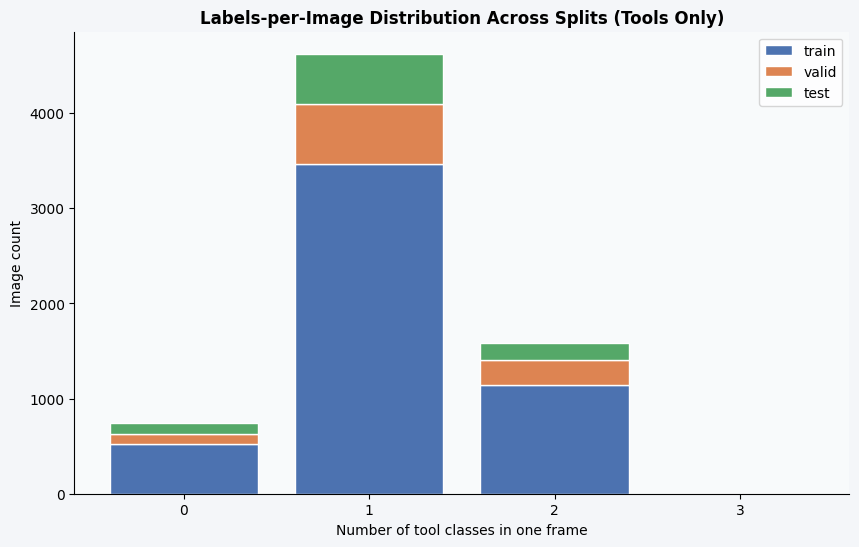

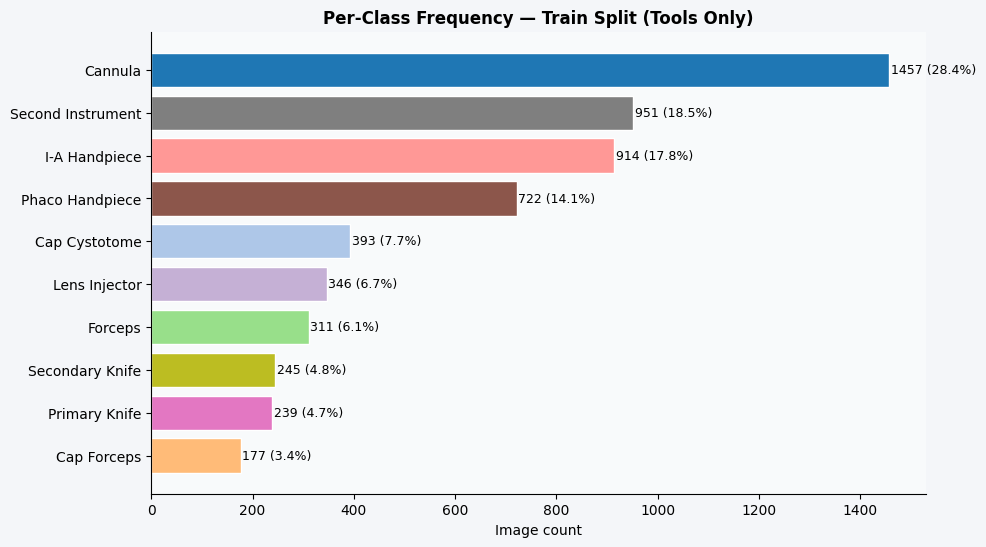

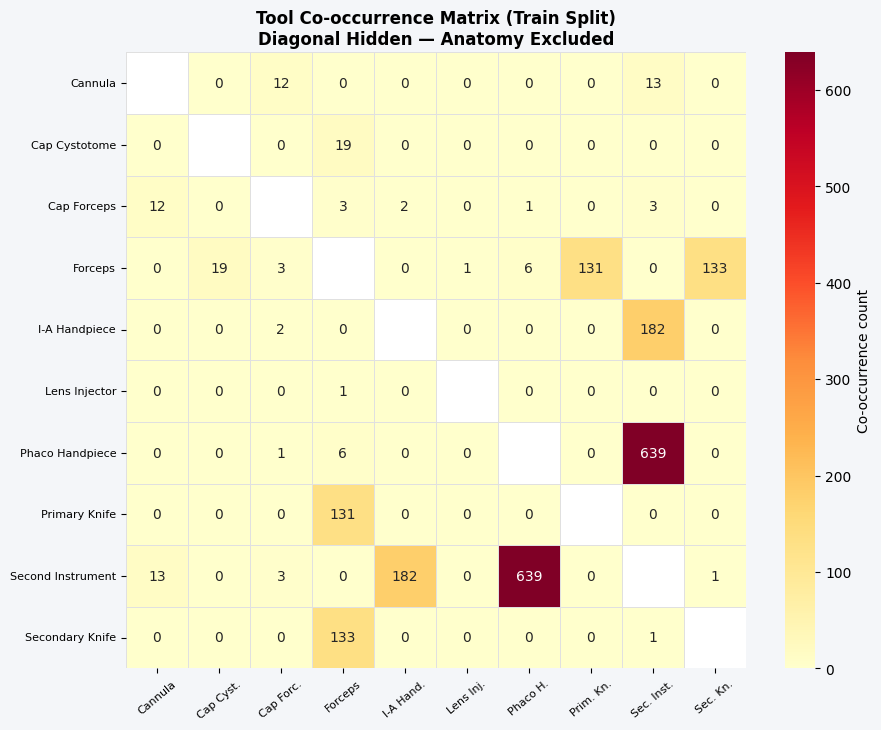

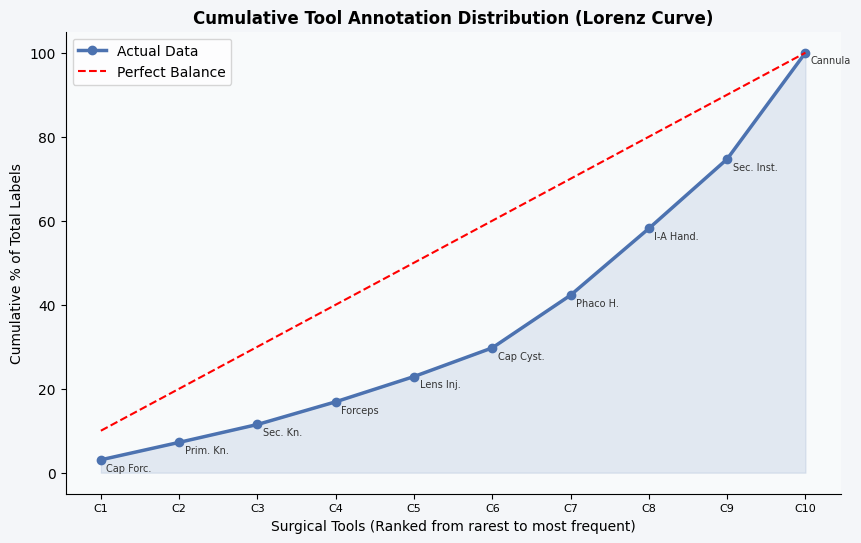

In [5]:
# SECTION 3*: FIG
# SURGICAL TOOLS ONLY

# FIG1: label per img

fig1, ax1 = plt.subplots(figsize=(10, 6))
fig1.patch.set_facecolor("#F4F6F9")
style_chart(ax1)

# max num of classes (will naturally be lower now that Cornea/Pupil are gone)
max_lbl = int(df_all["n_labels"].max())
x_vals  = list(range(max_lbl + 1))
bottom  = np.zeros(len(x_vals))

# chart for all splits
for s in SPLITS:
    lc = dfs[s]["n_labels"].value_counts().reindex(x_vals, fill_value=0)
    ax1.bar(x_vals, lc.values, bottom=bottom, label=s, color=SP_COLORS[s], edgecolor="white")
    bottom += lc.values  

# labels and titles
ax1.set_title("Labels-per-Image Distribution Across Splits (Tools Only)", fontweight="bold")
ax1.set_xlabel("Number of tool classes in one frame")
ax1.set_ylabel("Image count")
ax1.set_xticks(x_vals)
ax1.legend()

plt.show()


# FIG2: per class freq (in train)

fig2, ax2 = plt.subplots(figsize=(10, 6))
fig2.patch.set_facecolor("#F4F6F9")
style_chart(ax2)

# sort classes (most to least freq)
sort_idx = np.argsort(train_counts)[::-1]
s_cls    = [CLASS_COLS[i] for i in sort_idx]
s_cnt    = [train_counts[i] for i in sort_idx]
s_cols   = [BAR_COLS[i] for i in sort_idx]

# draw (will automatically show only the 10 actual tools)
hb = ax2.barh(s_cls, s_cnt, color=s_cols, edgecolor="white")
ax2.set_title("Per-Class Frequency — Train Split (Tools Only)", fontweight="bold")
ax2.set_xlabel("Image count")
ax2.invert_yaxis()

# add nums
for bar, v in zip(hb, s_cnt):
    pct = (v / len(dfs['train'])) * 100
    ax2.text(v + 3, bar.get_y() + bar.get_height()/2, f"{int(v)} ({pct:.1f}%)", va="center", fontsize=9)

plt.show()


# FIG3: Co-occurrence Heatmap

fig3, ax3 = plt.subplots(figsize=(10, 8))
fig3.patch.set_facecolor("#F4F6F9")

# hiding the class matching itself (now a clean 10x10 matrix mask)
mask = np.eye(N, dtype=bool)

# update short labels for the x-axis to match our filtered tools
S_LABELS_FILTERED = [SHORT.get(c, c) for c in CLASS_COLS]

# draw
sns.heatmap(co_df, ax=ax3, annot=True, fmt="d", cmap="YlOrRd",
            mask=mask, linewidths=0.6, linecolor="#e0e0e0",
            xticklabels=S_LABELS_FILTERED, yticklabels=CLASS_COLS,
            cbar_kws={"label": "Co-occurrence count"})

ax3.set_title("Tool Co-occurrence Matrix (Train Split)\nDiagonal Hidden — Anatomy Excluded", fontweight="bold")
ax3.tick_params(axis="x", rotation=40, labelsize=8)
ax3.tick_params(axis="y", rotation=0, labelsize=8)

plt.show()


# FIGURE 4: Lorenz Curve (Imbalance Diagnostics)

fig4, ax4 = plt.subplots(figsize=(10, 6))
fig4.patch.set_facecolor("#F4F6F9")
style_chart(ax4)

# cumulative percentages
sorted_counts = np.sort(train_counts)
cum_pct = np.cumsum(sorted_counts) / sorted_counts.sum() * 100

# data set line in blue
ax4.plot(range(1, N+1), cum_pct, marker="o", color="#4C72B0", linewidth=2.5, label="Actual Data")
ax4.fill_between(range(1, N+1), cum_pct, alpha=0.13, color="#4C72B0")

# ideal data set in red
ax4.plot([1, N], [100/N, 100], "r--", linewidth=1.5, label="Perfect Balance")

# label
ax4.set_xticks(range(1, N+1))
ax4.set_xticklabels([f"C{i+1}" for i in range(N)], fontsize=8)
ax4.set_xlabel("Surgical Tools (Ranked from rarest to most frequent)")
ax4.set_ylabel("Cumulative % of Total Labels")
ax4.set_title("Cumulative Tool Annotation Distribution (Lorenz Curve)", fontweight="bold")
ax4.legend()

ranked_cls = [CLASS_COLS[j] for j in np.argsort(train_counts)]
for i, (xp, yp, cls) in enumerate(zip(range(1, N+1), cum_pct, ranked_cls)):
    ax4.annotate(SHORT.get(cls, cls), (xp, yp), textcoords="offset points", 
                 xytext=(4, -8), fontsize=7, color="#333333")

plt.show()
